# - Business Problem

#### Many companies receive thousands of vendor invoices every month. Checking every invoice manually takes a lot of time and effort. Sometimes invoices contain unusual freight charges, incorrect costs, or delayed deliveries, which can lead to financial losses or fraud.

# - Objective

### **(Flagging Vendor Invoice for Manual Review)**

#### Build a machine learning model that predicts whether a vendor invoice should be flagged for manual review based on invoice details such as cost, freight, quantity, or delivery information.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
conn= sqlite3.connect("C:/Users/Dell/Desktop/ML/Vendor invoice intelligence system/data/inventory.db")
tables= pd.read_sql_query(" select name from sqlite_master where type='table'", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print(f'\nTable : {table}\n')
    df= pd.read_sql_query(f"select * from {table} limit  5", conn)
    display(df)


Table : purchases



,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



Table : purchase_prices



,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



Table : vendor_invoice



,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None



Table : begin_inventory



,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



Table : end_inventory



,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchases_agg_df= pd.read_sql_query("""

  SELECT 
       PONumber,
       COUNT( DISTINCT Brand) AS total_brands,
       SUM(Quantity) As total_quantity,
       SUM(Dollars) AS total_Dollars,
       AVG(julianday(ReceivingDate) - julianday(PODate)) AS avg_receiving_delays
  FROM purchases
  GROUP BY PONumber
       
""", conn)

In [6]:
purchases_agg_df.shape

(5543, 5)

In [7]:
pd.read_sql_query("select * from vendor_invoice", conn).shape

(5543, 10)

In [8]:
df = pd.read_sql_query("""

WITH purchase_agg AS (
    SELECT
        PONumber,
        COUNT(DISTINCT Brand) AS total_brands,
        SUM(Quantity) AS total_quantity,
        SUM(Dollars) AS total_purchase_amount,
        AVG(julianday(ReceivingDate) - julianday(PODate)) AS avg_receiving_days
    FROM purchases
    GROUP BY PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS po_to_invoice_days,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS payment_days,

    pa.total_brands,
    pa.total_quantity,
    pa.total_purchase_amount,
    pa.avg_receiving_days

FROM vendor_invoice AS vi

LEFT JOIN purchase_agg AS pa
ON vi.PONumber = pa.PONumber
""", conn)

In [9]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,po_to_invoice_days,payment_days,total_brands,total_quantity,total_purchase_amount,avg_receiving_days
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [10]:
df.isnull().sum()

PONumber                 0
invoice_quantity         0
invoice_dollars          0
Freight                  0
po_to_invoice_days       0
payment_days             0
total_brands             0
total_quantity           0
total_purchase_amount    0
avg_receiving_days       0
dtype: int64

In [11]:
df.dtypes

PONumber                   int64
invoice_quantity           int64
invoice_dollars          float64
Freight                  float64
po_to_invoice_days       float64
payment_days             float64
total_brands               int64
total_quantity             int64
total_purchase_amount    float64
avg_receiving_days       float64
dtype: object

In [12]:
def create_invoice_risk_label(row):

    # Mismatch in amount(dollars)
    if abs(row['invoice_dollars'] - row['total_purchase_amount']) >5 :
        return 1

    # High receiving delays
    if row['avg_receiving_days']>10 :                    
        return 1

    return 0

In [13]:
df['flag_invoice']= df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

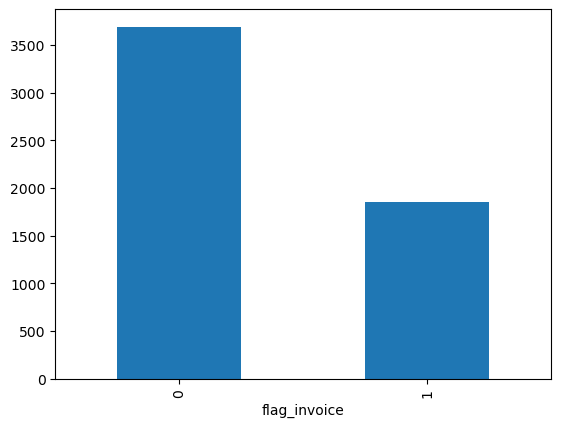

In [14]:
df['flag_invoice'].value_counts().plot(kind='bar')

<Axes: >

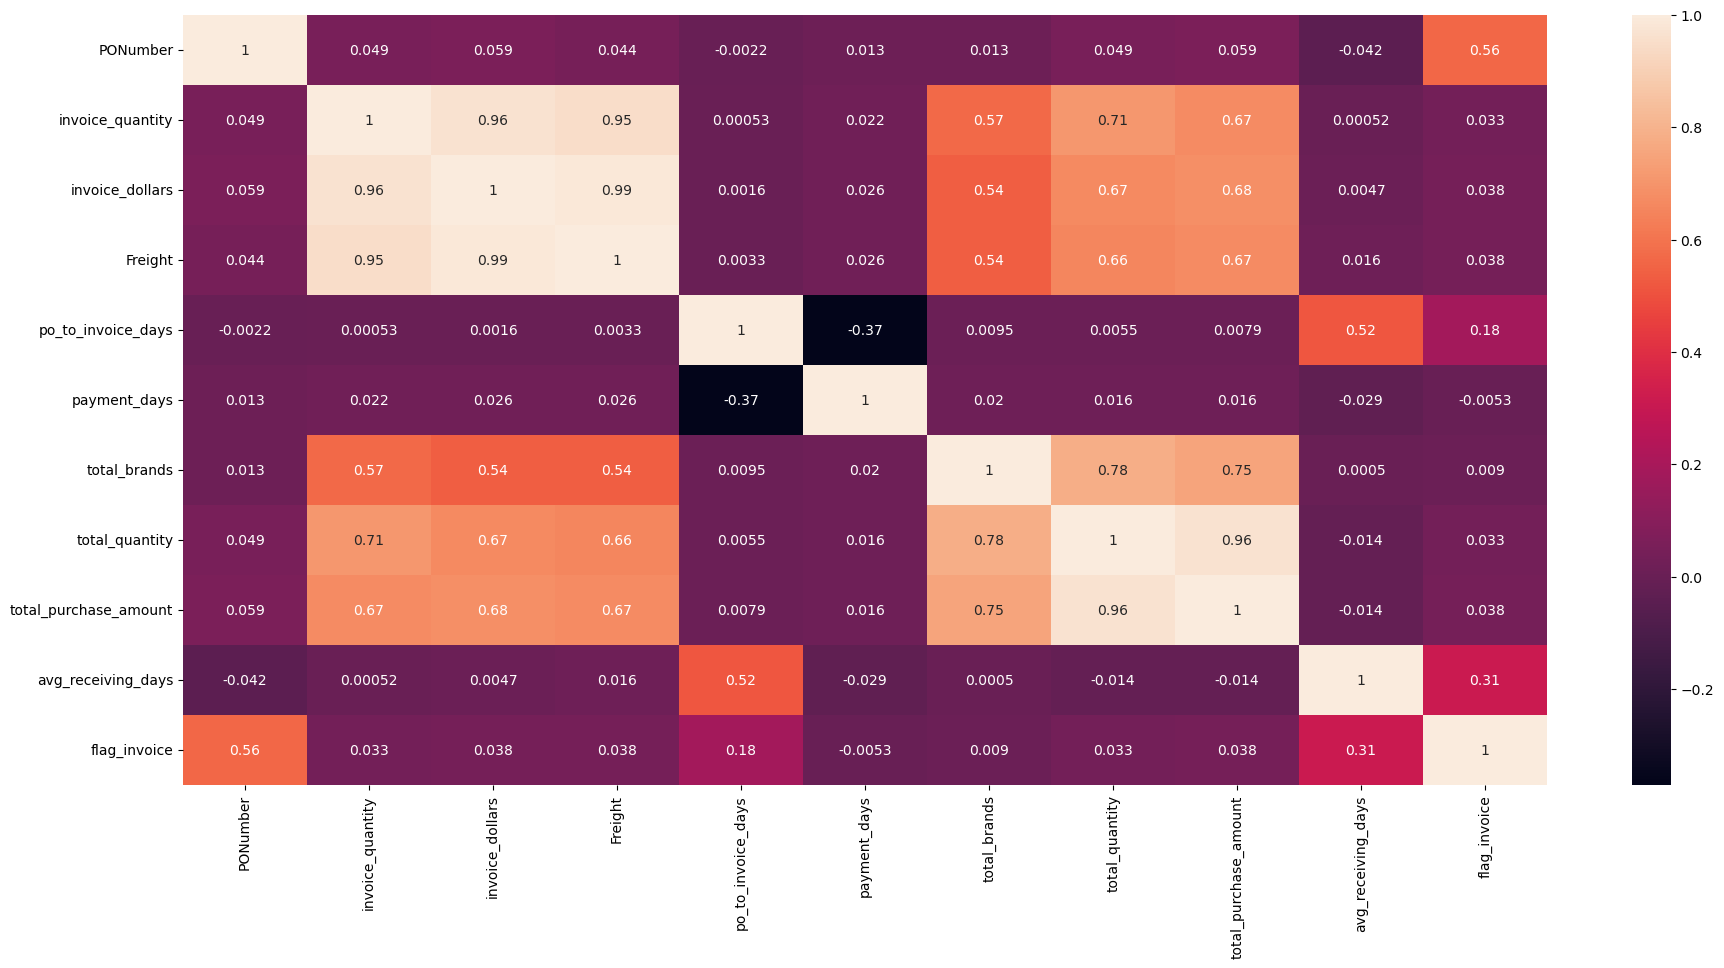

In [15]:
plt.figure(figsize=(22,10))
sns.heatmap(df.corr(), annot= True)

In [16]:
flagged= df[df['flag_invoice']== 1]
non_flagged= df[df['flag_invoice']== 0]

In [17]:
metrics=['invoice_quantity', 'invoice_dollars', 'Freight',
       'po_to_invoice_days', 'payment_days', 'total_brands', 'total_quantity',
       'total_purchase_amount', 'avg_receiving_days']

In [18]:
significant_features=[]
non_significant_features=[]
result=[]

In [19]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    non_flagged_mean = non_flagged[metric].mean()

    t_stat, p_value = ttest_ind( flagged[metric].dropna(), non_flagged[metric].dropna(), equal_var=False )

    if p_value < 0.05:
        significant_features.append(metric)
        result.append({
            "metric": metric,
            "flagged mean": round(flagged_mean,2),
            "Non flagged mean": round(non_flagged_mean,2),
            "p value":round(p_value,2)
        })

    else:
        non_significant_features.append(metric)
        print({
            "metric":metric,
            "flagged mean": round(flagged_mean,2),
            "Non flagged mean": round(non_flagged_mean,2)
        })


{'metric': 'payment_days', 'flagged mean': 35.42, 'Non flagged mean': 35.49}
{'metric': 'total_brands', 'flagged mean': 42.29, 'Non flagged mean': 40.82}


In [20]:
non_significant_features

['payment_days', 'total_brands']

In [21]:
result

[{'metric': 'invoice_quantity',
  'flagged mean': 6728.28,
  'Non flagged mean': 5723.55,
  'p value': 0.02},
 {'metric': 'invoice_dollars',
  'flagged mean': 65600.61,
  'Non flagged mean': 54302.64,
  'p value': 0.01},
 {'metric': 'Freight',
  'flagged mean': 334.02,
  'Non flagged mean': 276.89,
  'p value': 0.01},
 {'metric': 'po_to_invoice_days',
  'flagged mean': 17.23,
  'Non flagged mean': 16.02,
  'p value': 0.0},
 {'metric': 'total_quantity',
  'flagged mean': 6728.28,
  'Non flagged mean': 5723.55,
  'p value': 0.02},
 {'metric': 'total_purchase_amount',
  'flagged mean': 65600.61,
  'Non flagged mean': 54302.64,
  'p value': 0.01},
 {'metric': 'avg_receiving_days',
  'flagged mean': 8.47,
  'Non flagged mean': 7.27,
  'p value': 0.0}]

In [22]:
X = df[[ "invoice_quantity","invoice_dollars","Freight","po_to_invoice_days","total_quantity","total_purchase_amount","avg_receiving_days"]]
y = df["flag_invoice"]

In [23]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,po_to_invoice_days,total_quantity,total_purchase_amount,avg_receiving_days
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)


model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)


model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {round(accuracy, 2)}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [26]:
evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")

evaluate_model(model2, X_test_scaled, y_test, "Decision Tree Classifier")

evaluate_model(model3, X_test_scaled, y_test, "Random Forest Classifier")


Logistic Regression Performance:
Accuracy : 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.83       739
           1       0.74      0.41      0.53       370

    accuracy                           0.76      1109
   macro avg       0.75      0.67      0.68      1109
weighted avg       0.75      0.76      0.73      1109


Decision Tree Classifier Performance:
Accuracy : 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       739
           1       0.94      0.92      0.93       370

    accuracy                           0.95      1109
   macro avg       0.95      0.95      0.95      1109
weighted avg       0.95      0.95      0.95      1109


Random Forest Classifier Performance:
Accuracy : 0.96

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       739
     

In [52]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model3.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
6,avg_receiving_days,0.290648
5,total_purchase_amount,0.199119
4,total_quantity,0.163001
0,invoice_quantity,0.119024
1,invoice_dollars,0.115339
2,Freight,0.085997
3,po_to_invoice_days,0.026872


In [58]:
X = df[["avg_receiving_days", "total_purchase_amount","total_quantity","invoice_quantity","invoice_dollars"]]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [60]:
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Random Forest Performance:
Accuracy : 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       739
           1       1.00      0.92      0.96       370

    accuracy                           0.97      1109
   macro avg       0.98      0.96      0.97      1109
weighted avg       0.97      0.97      0.97      1109

